# Chapter 1: Radiative Transfer — The Physical Forward Model
### Bayesian Remote Sensing Curriculum

The forward model F(x) is the radiative transfer equation. Before we can do any
Bayesian retrieval, we need to understand what the satellite actually measures.

This notebook builds:
1. The Planck function — thermal emission at any temperature
2. Beer-Lambert law and optical depth
3. Simplified 1D thermal IR radiance calculation
4. Weighting functions — where in the atmosphere do different channels "see"?
5. AOD spectral dependence — the Ångström exponent


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, constants

# Physical constants
h   = constants.h          # Planck constant [J·s]
c   = constants.c * 100    # Speed of light [cm/s]
kB  = constants.k          # Boltzmann constant [J/K]
c1  = 2 * h * c**2         # First radiation constant
c2  = h * c / kB           # Second radiation constant [cm·K]

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})
print(f"c2 = h*c/k = {c2:.2f} cm·K")
print(f"Wien peak for T=250 K: nu_peak = 1.96 * T / c2 = {1.96*250/c2:.0f} cm-1")


c2 = h*c/k = 1.44 cm·K
Wien peak for T=250 K: nu_peak = 1.96 * T / c2 = 341 cm-1


## 1.1 The Planck Function

The spectrum of thermal emission at temperature T:

$$B(\nu, T) = \frac{2hc^2\nu^3}{\exp(hc\nu/kT) - 1}$$

This is what the atmosphere and surface emit. The satellite measures the
radiance reaching the top of the atmosphere — a mixture of surface emission
and atmospheric emission at various temperatures.


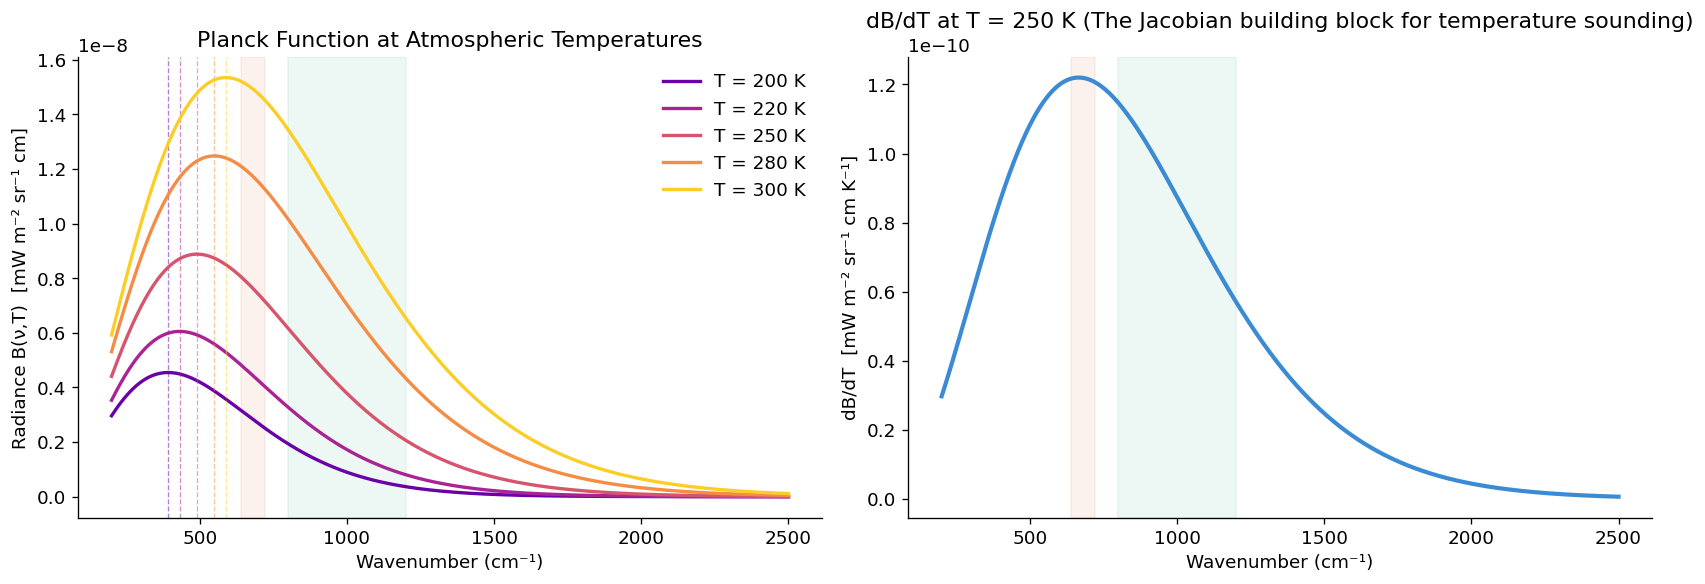

Planck function at key channels:
  900 cm-1 (window),  T=290K:  B = 0.01 mW m-2 sr-1 cm
  667 cm-1 (CO2 core), T=250K: B = 0.01 mW m-2 sr-1 cm


In [3]:
# Planck function
def planck(nu, T):
    return c1 * nu**3 / (np.expm1(c2 * nu / T))

nu = np.linspace(200, 2500, 2000)   # wavenumber (cm-1)
temps = [200, 220, 250, 280, 300]
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(temps)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full spectrum
for T, col in zip(temps, colors):
    B = planck(nu, T) * 1e-3   # to mW m-2 sr-1 cm
    axes[0].plot(nu, B, color=col, lw=2, label=f"T = {T} K")
    # Mark peak
    nu_peak = nu[np.argmax(B)]
    axes[0].axvline(nu_peak, color=col, lw=0.8, ls="--", alpha=0.5)

axes[0].set_xlabel("Wavenumber (cm⁻¹)")
axes[0].set_ylabel("Radiance B(ν,T)  [mW m⁻² sr⁻¹ cm]")
axes[0].set_title("Planck Function at Atmospheric Temperatures")
axes[0].legend(frameon=False)

# Spectral derivative dB/dT — important for Jacobians
for T, col in zip([250], ["#3B8BD4"]):
    dBdT = c1 * nu**3 * c2 * nu / T**2 / (np.expm1(c2*nu/T)**2) * np.exp(c2*nu/T)
    dBdT *= 1e-3
    axes[1].plot(nu, dBdT, color=col, lw=2.5)
    axes[1].set_title("dB/dT at T = 250 K (The Jacobian building block for temperature sounding)")
    axes[1].set_xlabel("Wavenumber (cm⁻¹)")
    axes[1].set_ylabel("dB/dT  [mW m⁻² sr⁻¹ cm K⁻¹]")

# Mark key atmospheric windows and absorption bands
for ax in axes:
    ax.axvspan(800, 1200, color="#1D9E75", alpha=0.08, label="8-12 μm window")
    ax.axvspan(640, 720, color="#D85A30", alpha=0.08, label="CO₂ 15 μm band")

plt.tight_layout()
plt.show()

# Brightness temperature conversion
def rad_to_BT(nu, B):
    return c2 * nu / np.log(1 + c1 * nu**3 / B)

print("Planck function at key channels:")
print(f"  900 cm-1 (window),  T=290K:  B = {planck(900,290)*1e3:.2f} mW m-2 sr-1 cm")
print(f"  667 cm-1 (CO2 core), T=250K: B = {planck(667,250)*1e3:.2f} mW m-2 sr-1 cm")


## 1.2 Beer-Lambert Law and Optical Depth

Radiation attenuates exponentially through an absorbing medium:

$$I(L) = I_0 \cdot e^{-\tau}, \quad \tau = \int_0^L k_{\text{abs}}(s)\,ds$$

The **transmittance** T = e^{-τ} ranges from 0 (opaque) to 1 (transparent).


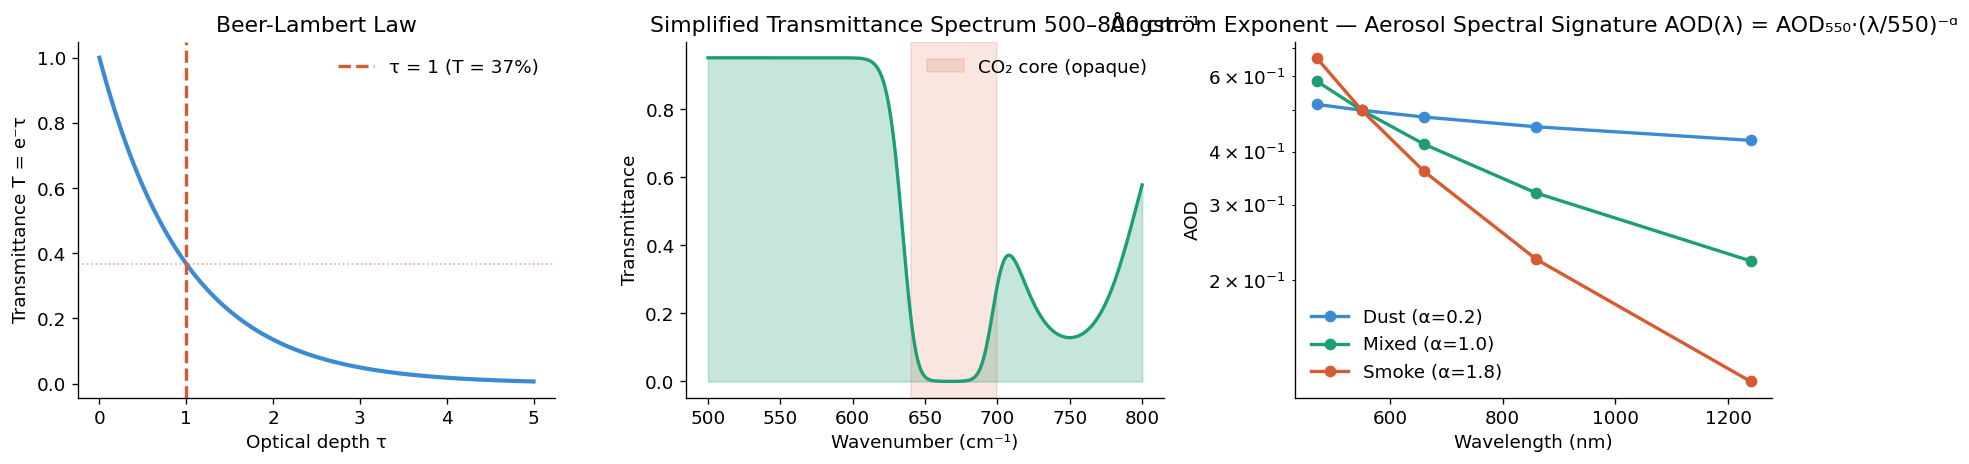

In [6]:
# Beer-Lambert: transmittance through different optical depths
tau_values = np.linspace(0, 5, 200)
transmittance = np.exp(-tau_values)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(tau_values, transmittance, "#3B8BD4", lw=2.5)
axes[0].axvline(1.0, color="#D85A30", lw=2, ls="--", label="τ = 1 (T = 37%)")
axes[0].axhline(1/np.e, color="#D85A30", lw=1, ls=":", alpha=0.5)
axes[0].set_xlabel("Optical depth τ"); axes[0].set_ylabel("Transmittance T = e⁻τ")
axes[0].set_title("Beer-Lambert Law")
axes[0].legend(frameon=False)

# Absorption spectrum — simplified CO2 + H2O profile
nu_fine = np.linspace(500, 800, 500)
# Simulate a simplified absorption spectrum
tau_co2 = 8 * np.exp(-((nu_fine - 667)**2)/(2*15**2))     # CO2 15um band
tau_h2o = 2 * np.exp(-((nu_fine - 750)**2)/(2*30**2))      # H2O rotation band
tau_total = tau_co2 + tau_h2o + 0.05                        # add window absorption

T_spec = np.exp(-tau_total)
axes[1].plot(nu_fine, T_spec, "#1D9E75", lw=2)
axes[1].fill_between(nu_fine, T_spec, alpha=0.25, color="#1D9E75")
axes[1].axvspan(640, 700, color="#D85A30", alpha=0.15, label="CO₂ core (opaque)")
axes[1].set_xlabel("Wavenumber (cm⁻¹)"); axes[1].set_ylabel("Transmittance")
axes[1].set_title("Simplified Transmittance Spectrum 500–800 cm⁻¹")
axes[1].legend(frameon=False)

# AOD vs wavelength: Ångström exponent
lambda_nm = np.array([470, 550, 660, 860, 1240])
AOD_550 = 0.5
alphas = [0.2, 1.0, 1.8]   # different aerosol types

for alpha, col, label in zip(alphas, ["#3B8BD4","#1D9E75","#D85A30"],
                              ["Dust (α=0.2)", "Mixed (α=1.0)", "Smoke (α=1.8)"]):
    AOD = AOD_550 * (lambda_nm / 550)**(-alpha)
    axes[2].semilogy(lambda_nm, AOD, 'o-', color=col, lw=2, label=label)

axes[2].set_xlabel("Wavelength (nm)"); axes[2].set_ylabel("AOD")
axes[2].set_title("Ångström Exponent — Aerosol Spectral Signature AOD(λ) = AOD₅₅₀·(λ/550)⁻ᵅ")
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()


## 1.3 Simplified Thermal IR Radiance Profile

A nadir-viewing satellite observes:

$$I_\text{TOA}(\nu) = \varepsilon_s B(\nu, T_s) t(\nu, p_s) + \int_0^{p_s} B(\nu, T(p)) \frac{\partial t(\nu, p)}{\partial p}\, dp$$

Let's build this for a 10-level atmosphere.


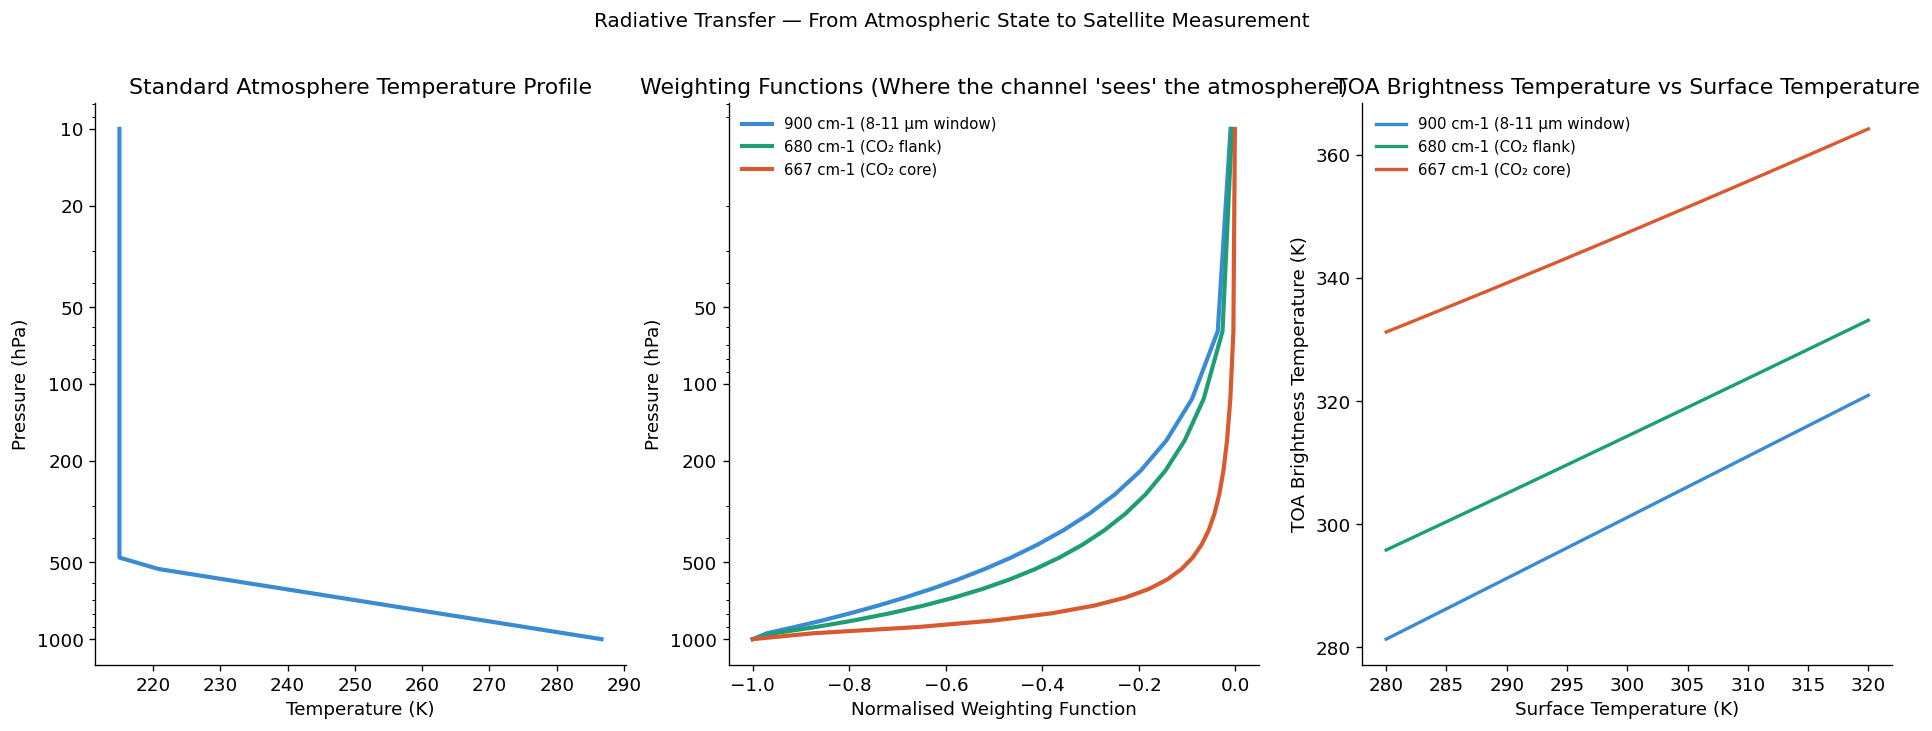

Key insight: The window channel BT tracks surface T closely.
The CO2 core channel is nearly insensitive to surface T — it sees the stratosphere.


In [11]:
# Simplified 10-level atmosphere — compute TOA brightness temperatures
n_levels = 20
p_levels = np.linspace(1000, 10, n_levels)      # pressure (hPa)
z_approx = 16 * np.log(1013/p_levels)            # approx height (km)

# Standard atmosphere temperature profile
T_std = 288 - 6.5 * z_approx                     # troposphere lapse rate
T_std = np.clip(T_std, 215, 300)                  # clamp to realistic range

# Simulate at 3 channels: window, CO2 flank, CO2 core
channels = {
    "900 cm-1 (8-11 μm window)":  (900, 0.08),
    "680 cm-1 (CO₂ flank)":       (680, 0.8),
    "667 cm-1 (CO₂ core)":        (667, 5.0),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
ax_T, ax_wf, ax_bt = axes

# Temperature profile
ax_T.plot(T_std, p_levels, "#3B8BD4", lw=2.5)
ax_T.invert_yaxis()
ax_T.set_yscale("log")
ax_T.set_xlabel("Temperature (K)"); ax_T.set_ylabel("Pressure (hPa)")
ax_T.set_title("Standard Atmosphere Temperature Profile")
ax_T.set_yticks([1000, 500, 200, 100, 50, 20, 10])
ax_T.set_yticklabels(["1000","500","200","100","50","20","10"])

colors_ch = ["#3B8BD4", "#1D9E75", "#D85A30"]

for (ch_name, (nu_ch, k_abs_col)), col in zip(channels.items(), colors_ch):
    # Build transmittance profile: t(p) = exp(-tau(p))
    # tau(p) = column absorption from p to TOA
    # k_abs proportional to pressure (collision broadening)
    k_profile = k_abs_col * p_levels / 1013.0
    dp = np.diff(p_levels, prepend=p_levels[0])
    tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
    t_profile = np.exp(-tau_cum[::-1])

    # Weighting function: dt/dp (where does the signal come from?)
    dt_dp = np.gradient(t_profile, p_levels)

    ax_wf.plot(-dt_dp / np.abs(-dt_dp).max(), p_levels, color=col, lw=2.5, label=ch_name)

    # TOA brightness temperature
    B_surface = planck(nu_ch, 295)   # surface emission
    B_atm     = planck(nu_ch, T_std)  # atmospheric emission at each level
    I_TOA = B_surface * t_profile[0]  + np.trapezoid(B_atm * (-np.gradient(t_profile, p_levels)),
                                                    p_levels)
    BT = rad_to_BT(nu_ch, I_TOA)

ax_wf.invert_yaxis()
ax_wf.set_yscale("log")
ax_wf.set_xlabel("Normalised Weighting Function")
ax_wf.set_ylabel("Pressure (hPa)")
ax_wf.set_title("Weighting Functions (Where the channel 'sees' the atmosphere)")
ax_wf.legend(frameon=False, fontsize=9)
ax_wf.set_yticks([1000, 500, 200, 100, 50])
ax_wf.set_yticklabels(["1000","500","200","100","50"])

# TOA BT as function of surface temperature perturbation
T_surface = np.linspace(280, 320, 50)
ax_bt.set_title("TOA Brightness Temperature vs Surface Temperature")
for (ch_name, (nu_ch, k_abs_col)), col in zip(channels.items(), colors_ch):
    BTs = []
    for Ts in T_surface:
        B_s = planck(nu_ch, Ts)
        k_profile = k_abs_col * p_levels / 1013.0
        dp = np.diff(p_levels, prepend=p_levels[0])
        tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
        t_p = np.exp(-tau_cum[::-1])
        B_atm = planck(nu_ch, T_std)
        I_TOA = B_s * t_p[0] + np.trapezoid(B_atm * (-np.gradient(t_p, p_levels)), p_levels)
        BTs.append(rad_to_BT(nu_ch, I_TOA))
    ax_bt.plot(T_surface, BTs, color=col, lw=2, label=ch_name)

ax_bt.set_xlabel("Surface Temperature (K)")
ax_bt.set_ylabel("TOA Brightness Temperature (K)")
ax_bt.legend(frameon=False, fontsize=9)

plt.suptitle("Radiative Transfer — From Atmospheric State to Satellite Measurement", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print("Key insight: The window channel BT tracks surface T closely.")
print("The CO2 core channel is nearly insensitive to surface T — it sees the stratosphere.")


## 1.4 Jacobians — The Bridge to Bayesian Retrieval

The Jacobian K_{ij} = ∂y_i/∂x_j tells us how sensitive measurement i is to
state variable j. This is the key matrix that connects the forward model to the
Bayesian update:

x̂ = x_a + G(y - F(x_a))  where  G = Sa Kᵀ(K Sa Kᵀ + Sε)⁻¹

A large |K_ij| means the measurement is sensitive to that state variable
→ the posterior will be much narrower than the prior for that variable.


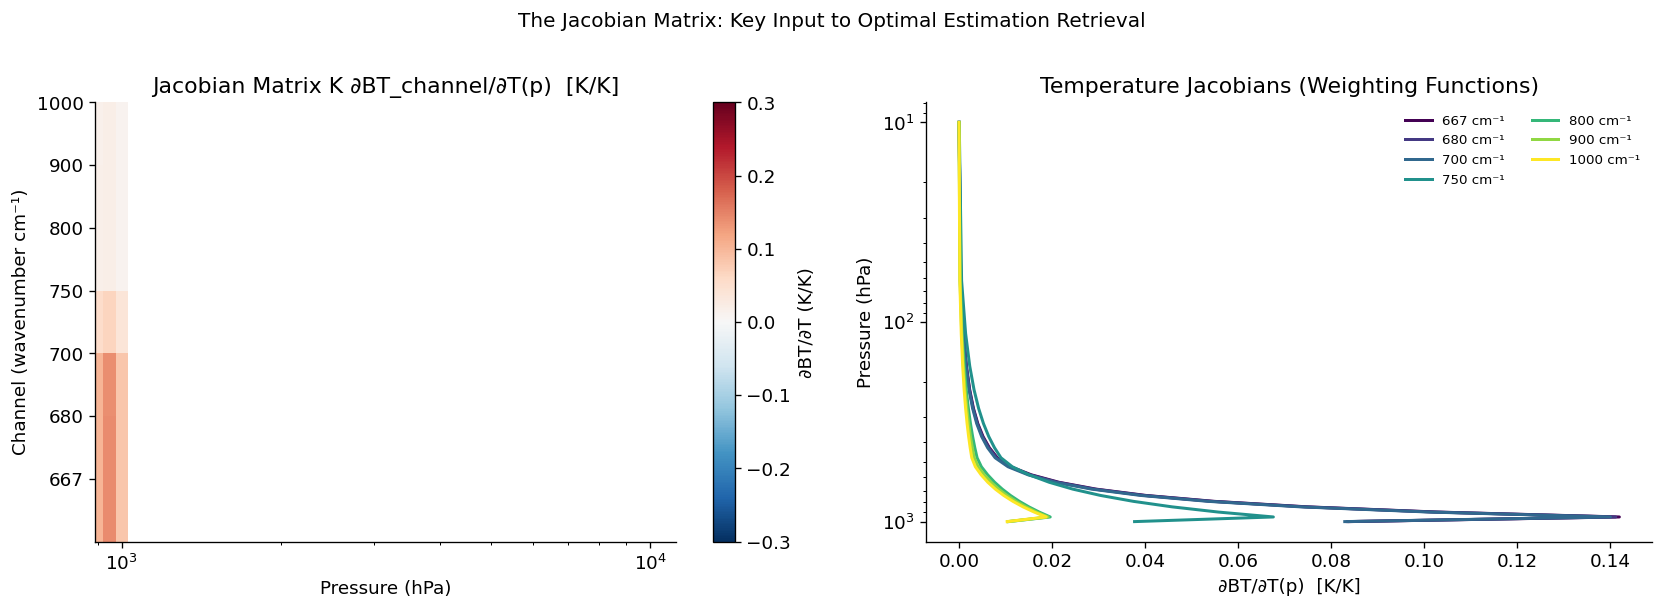

Jacobian shape: (7, 20) (channels × pressure levels)
The retrieval can only determine ~d_s independent combinations of the profile,
where d_s = trace(A) = trace(Sa K^T Se^{-1} K) is the degrees of freedom for signal.


In [13]:
# Jacobian dBT/dT(p): how does each pressure level's temperature affect each channel BT?
nu_channels = np.array([667, 680, 700, 750, 800, 900, 1000])
ch_labels   = [f"{nu}" for nu in nu_channels]

n_ch = len(nu_channels)
n_p  = len(p_levels)
K    = np.zeros((n_ch, n_p))

delta_T = 1.0   # 1K perturbation

for i, nu_ch in enumerate(nu_channels):
    k_col = 0.5 if nu_ch > 750 else (2.0 if nu_ch > 700 else 5.0)
    k_profile = k_col * p_levels / 1013.0
    dp = np.diff(p_levels, prepend=p_levels[0])
    tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
    t_p = np.exp(-tau_cum[::-1])

    for j in range(n_p):
        T_pert = T_std.copy()
        T_pert[j] += delta_T
        B_atm_pert = planck(nu_ch, T_pert)
        B_atm_base = planck(nu_ch, T_std)
        I_base = planck(nu_ch, 295)*t_p[0] + np.trapezoid(B_atm_base*(-np.gradient(t_p,p_levels)), p_levels)
        I_pert = planck(nu_ch, 295)*t_p[0] + np.trapezoid(B_atm_pert*(-np.gradient(t_p,p_levels)), p_levels)
        BT_base = rad_to_BT(nu_ch, I_base)
        BT_pert = rad_to_BT(nu_ch, I_pert)
        K[i, j] = (BT_pert - BT_base) / delta_T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].pcolormesh(p_levels, np.arange(n_ch), K,
                         cmap="RdBu_r", vmin=-0.3, vmax=0.3)
axes[0].set_xlabel("Pressure (hPa)")
axes[0].set_ylabel("Channel (wavenumber cm⁻¹)")
axes[0].set_yticks(np.arange(n_ch)+0.5)
axes[0].set_yticklabels(ch_labels)
axes[0].set_xscale("log")
axes[0].set_title("Jacobian Matrix K ∂BT_channel/∂T(p)  [K/K]")
plt.colorbar(im, ax=axes[0], label="∂BT/∂T (K/K)")

# Individual weighting functions per channel
for i, (nu_ch, col) in enumerate(zip(nu_channels,
    plt.cm.viridis(np.linspace(0,1,n_ch)))):
    axes[1].plot(K[i], p_levels, color=col, lw=1.8, label=f"{nu_ch} cm⁻¹")

axes[1].invert_yaxis()
axes[1].set_yscale("log")
axes[1].set_xlabel("∂BT/∂T(p)  [K/K]")
axes[1].set_ylabel("Pressure (hPa)")
axes[1].set_title("Temperature Jacobians (Weighting Functions)")
axes[1].legend(frameon=False, fontsize=8, ncol=2)

plt.suptitle("The Jacobian Matrix: Key Input to Optimal Estimation Retrieval",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print("Jacobian shape:", K.shape, "(channels × pressure levels)")
print("The retrieval can only determine ~d_s independent combinations of the profile,")
print("where d_s = trace(A) = trace(Sa K^T Se^{-1} K) is the degrees of freedom for signal.")


In [14]:
print("Chapter 1 complete!")
print()
print("Summary of the forward model:")
print("  y = F(x) + ε")
print("  y: measured BTs or reflectances")
print("  x: atmospheric state (T, gases, aerosols, surface)")
print("  F: radiative transfer (Beer-Lambert + Planck emission)")
print("  ε: instrument noise ~ N(0, Sε)")
print()
print("Key physics:")
print("  - Weighting function peaks at τ ≈ 1")
print("  - Window channels see the surface")
print("  - CO₂ core channel sees the stratosphere")
print("  - Different channels = independent information = vertical resolution")


Chapter 1 complete!

Summary of the forward model:
  y = F(x) + ε
  y: measured BTs or reflectances
  x: atmospheric state (T, gases, aerosols, surface)
  F: radiative transfer (Beer-Lambert + Planck emission)
  ε: instrument noise ~ N(0, Sε)

Key physics:
  - Weighting function peaks at τ ≈ 1
  - Window channels see the surface
  - CO₂ core channel sees the stratosphere
  - Different channels = independent information = vertical resolution
